# Desafio Alliage — U-Net otimizada para CPU

Esta é a versão do notebook preparada para executar no **Google Colab usando CPU** e gerar os artefatos obrigatórios de avaliação do desafio.

Principais características:

- imagens reduzidas para **256 × 512**;
- U-Net multiclasse leve (`base_channels=16`);
- **33 classes**: fundo + 32 posições dentárias;
- **CrossEntropy ponderada** no treinamento;
- Dice e IoU calculados de forma vetorizada por matriz de confusão;
- divisão independente em **treino / validação / teste final anotado**;
- validação periódica, scheduler e **Early Stopping**;
- seleção automática do melhor checkpoint pela validation loss;
- **Dice final calculado apenas após carregar o melhor modelo e apenas no teste reservado**;
- Dice/IoU por radiografia;
- três exemplos automáticos no formato **Original | Predição | Ground Truth**;
- seleção automática do **pior caso** pelo menor Dice;
- salvamento das métricas e figuras em `results/`.

> Execute as células em ordem. Antes do treinamento, confira visualmente a máscara gerada.


In [1]:
# 1. Imports
from pathlib import Path
import json
import random
import time
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())

PyTorch: 2.11.0+cpu
CUDA disponível: False


In [2]:
# 2. Configuração da CPU

CPU_COUNT = os.cpu_count() or 2

# Para este notebook, deixamos o DataLoader no processo principal
# para que o cache do Dataset seja realmente compartilhado entre as épocas.
# Assim, o PyTorch pode usar os núcleos disponíveis nas convoluções.
NUM_THREADS = max(1, CPU_COUNT)
NUM_WORKERS = 0

torch.set_num_threads(NUM_THREADS)

print("CPUs disponíveis:", CPU_COUNT)
print("Threads usadas pelo PyTorch:", torch.get_num_threads())
print("Workers do DataLoader:", NUM_WORKERS)

CPUs disponíveis: 2
Threads usadas pelo PyTorch: 2
Workers do DataLoader: 0


In [3]:
# 3. Configurações

SEED = 42

# ==========================
# CAMINHOS DO DATASET
# ==========================
TRAIN_IMAGES_DIR = Path("dataset/train/images")
TRAIN_ANNOTATIONS_DIR = Path("dataset/train/annotations")
TEST_IMAGES_DIR = Path("dataset/test/images")

# ==========================
# TAMANHO DAS IMAGENS
# ==========================
# Originais: 1024 x 2048
# Versão rápida para CPU, mantendo a proporção 2:1.
IMG_HEIGHT = 256
IMG_WIDTH = 512

# ==========================
# TREINAMENTO
# ==========================
NUM_CLASSES = 33       # 0 = fundo + 32 dentes
BATCH_SIZE = 4
LEARNING_RATE = 1e-3
EPOCHS = 15

# Early stopping é contado somente nas épocas em que há validação.
PATIENCE = 3

# Faz a validação completa a cada 2 épocas para economizar CPU.
VALIDATE_EVERY = 2

DEVICE = torch.device("cpu")

print("Device:", DEVICE)
print("Resolução de treinamento:", IMG_HEIGHT, "x", IMG_WIDTH)
print("Batch size:", BATCH_SIZE)
print("Máximo de épocas:", EPOCHS)

Device: cpu
Resolução de treinamento: 256 x 512
Batch size: 4
Máximo de épocas: 15


In [4]:
# 4. Reprodutibilidade

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Conversão COCO JSON → máscara

Cada anotação possui um `category_id` e polígonos no campo `segmentation`.

A máscara resultante utiliza:

- `0`: fundo;
- `1..32`: classes dos dentes.


In [5]:
# 5. Converter COCO JSON em máscara multiclasse

def coco_to_mask(json_path):
    json_path = Path(json_path)

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    image_info = data["images"][0]
    height = int(image_info["height"])
    width = int(image_info["width"])

    mask = np.zeros((height, width), dtype=np.uint8)

    for annotation in data.get("annotations", []):
        category_id = int(annotation["category_id"])
        segmentation = annotation.get("segmentation", [])

        if not isinstance(segmentation, list):
            continue

        for polygon in segmentation:
            if not isinstance(polygon, list) or len(polygon) < 6:
                continue

            points = np.asarray(
                polygon,
                dtype=np.float32
            ).reshape(-1, 2)

            points = np.round(points).astype(np.int32)

            cv2.fillPoly(
                mask,
                [points],
                color=category_id
            )

    return mask

## Dataset com cache

A primeira vez que uma imagem é acessada:

1. a imagem é lida e redimensionada;
2. o JSON é convertido em máscara;
3. a máscara é redimensionada;
4. ambos são guardados em memória.

Nas épocas seguintes, o notebook reutiliza os tensores em cache e não precisa reconstruir os polígonos novamente.


In [6]:
# 6. Dataset PyTorch otimizado com cache

class DentalDataset(Dataset):

    def __init__(
        self,
        images_dir,
        annotations_dir,
        img_height=256,
        img_width=512
    ):
        self.images_dir = Path(images_dir)
        self.annotations_dir = Path(annotations_dir)

        self.img_height = img_height
        self.img_width = img_width

        self.samples = []

        # Cache compartilhado enquanto NUM_WORKERS = 0.
        self.image_cache = {}
        self.mask_cache = {}

        json_files = sorted(
            self.annotations_dir.glob("*.json")
        )

        for json_path in json_files:

            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            image_filename = data["images"][0]["file_name"]
            image_path = self.images_dir / image_filename

            # Caso o arquivo local tenha um sufixo adicional.
            if not image_path.exists():

                stem = Path(image_filename).stem

                candidates = [
                    p
                    for p in self.images_dir.glob(stem + "*")
                    if p.suffix.lower()
                    in {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
                ]

                if not candidates:
                    print(
                        "[AVISO] Imagem não encontrada:",
                        image_filename
                    )
                    continue

                image_path = candidates[0]

            self.samples.append(
                (image_path, json_path)
            )

        print(
            f"{len(self.samples)} pares imagem/anotação encontrados."
        )


    def __len__(self):
        return len(self.samples)


    def __getitem__(self, idx):

        idx = int(idx)

        # Se já processamos esta amostra, reutilizamos o cache.
        if (
            idx in self.image_cache
            and idx in self.mask_cache
        ):
            return (
                self.image_cache[idx],
                self.mask_cache[idx]
            )

        image_path, json_path = self.samples[idx]

        # ==========================
        # IMAGEM
        # ==========================
        image = cv2.imread(
            str(image_path),
            cv2.IMREAD_GRAYSCALE
        )

        if image is None:
            raise FileNotFoundError(
                f"Não foi possível abrir: {image_path}"
            )

        image = cv2.resize(
            image,
            (self.img_width, self.img_height),
            interpolation=cv2.INTER_AREA
        )

        image = image.astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=0)

        image = torch.from_numpy(image).float()

        # ==========================
        # MÁSCARA
        # ==========================
        mask = coco_to_mask(json_path)

        # Máscaras categóricas devem usar NEAREST.
        mask = cv2.resize(
            mask,
            (self.img_width, self.img_height),
            interpolation=cv2.INTER_NEAREST
        )

        mask = torch.from_numpy(mask).long()

        # ==========================
        # CACHE
        # ==========================
        self.image_cache[idx] = image
        self.mask_cache[idx] = mask

        return image, mask

In [8]:
# 7. Criar dataset

dataset = DentalDataset(
    TRAIN_IMAGES_DIR,
    TRAIN_ANNOTATIONS_DIR,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH
)

print("Número de amostras:", len(dataset))

if len(dataset) == 0:
    raise ValueError(
        "Nenhum par imagem/anotação foi encontrado. "
        "Confira os caminhos em TRAIN_IMAGES_DIR e TRAIN_ANNOTATIONS_DIR."
    )

30 pares imagem/anotação encontrados.
Número de amostras: 30


In [9]:
# 8. Conferir uma amostra

image, mask = dataset[0]

print("Shape da imagem:", image.shape)
print("Shape da máscara:", mask.shape)
print("Classes encontradas:", torch.unique(mask).tolist())

Shape da imagem: torch.Size([1, 256, 512])
Shape da máscara: torch.Size([256, 512])
Classes encontradas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]


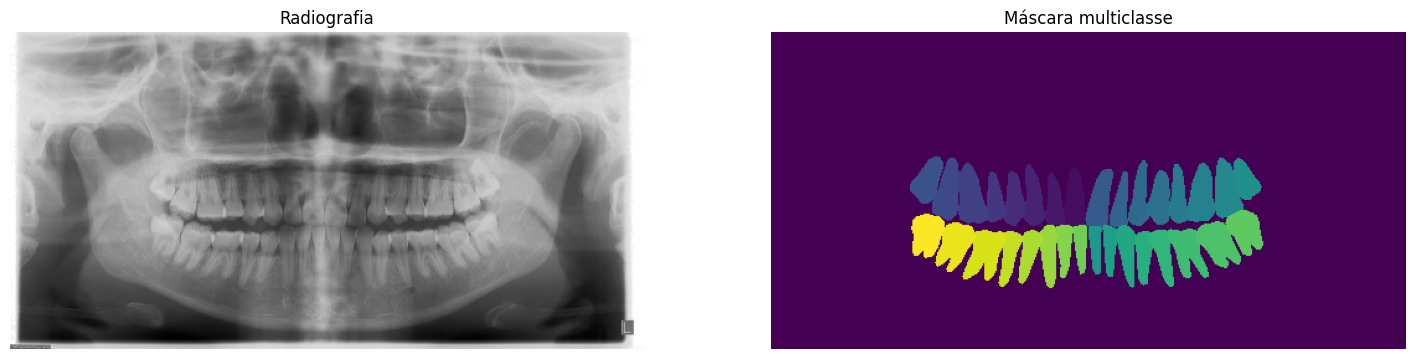

In [10]:
# 9. Visualizar imagem e máscara antes do treinamento

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.imshow(image.squeeze().numpy(), cmap="gray")
plt.title("Radiografia")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    mask.numpy(),
    vmin=0,
    vmax=NUM_CLASSES - 1
)
plt.title("Máscara multiclasse")
plt.axis("off")

plt.show()

## Treino, validação e teste anotado

O conjunto **anotado** é dividido de forma determinística e sem sobreposição em três partes:

- **70% treino**: usado para atualizar os pesos da rede;
- **15% validação**: usado para scheduler, early stopping e seleção do melhor checkpoint;
- **15% teste final**: fica completamente isolado até o fim e é usado somente para medir Dice/IoU e gerar as figuras da apresentação.

> A pasta `dataset/test/images` continua sendo usada apenas para inferência em radiografias externas sem anotação. Ela não entra no cálculo das métricas porque não possui Ground Truth.


In [11]:
# 10. Separar treino, validação e teste final anotado

if len(dataset) < 3:
    raise ValueError(
        "São necessárias pelo menos 3 imagens anotadas "
        "para criar treino, validação e teste."
    )

# Aproximadamente 70% / 15% / 15%, garantindo ao menos
# uma amostra em validação e uma no teste.
val_size = max(1, int(round(0.15 * len(dataset))))
test_size = max(1, int(round(0.15 * len(dataset))))
train_size = len(dataset) - val_size - test_size

# Para datasets muito pequenos, garante ao menos uma imagem de treino.
if train_size < 1:
    train_size = 1
    remaining = len(dataset) - train_size
    val_size = max(1, remaining // 2)
    test_size = remaining - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Treino:", len(train_dataset))
print("Validação:", len(val_dataset))
print("Teste final anotado:", len(test_dataset))
print(
    "Total:",
    len(train_dataset) + len(val_dataset) + len(test_dataset)
)


Treino: 22
Validação: 4
Teste final anotado: 4
Total: 30


In [12]:
# 11. DataLoaders

# NUM_WORKERS = 0 é intencional:
# mantém um único cache do Dataset e evita overhead de processos
# em runtimes de CPU pequenos, como o Colab.

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

# Batch size 1 facilita o cálculo e o armazenamento das
# métricas por radiografia no teste final.
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

print("Batches de treino:", len(train_loader))
print("Batches de validação:", len(val_loader))
print("Batches de teste final:", len(test_loader))


Batches de treino: 6
Batches de validação: 1
Batches de teste final: 4


## U-Net leve

A arquitetura continua sendo uma U-Net, mas usa `base_channels=16`, reduzindo bastante o custo de CPU em relação à versão anterior com 32 canais iniciais.


In [13]:
# 12. Bloco convolucional

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [14]:
# 13. U-Net

class UNet(nn.Module):

    def __init__(
        self,
        in_channels=1,
        num_classes=33,
        base_channels=16
    ):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(
            in_channels,
            base_channels
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(
            base_channels,
            base_channels * 2
        )
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(
            base_channels * 2,
            base_channels * 4
        )
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(
            base_channels * 4,
            base_channels * 8
        )
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(
            base_channels * 8,
            base_channels * 16
        )

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            base_channels * 16,
            base_channels * 8,
            kernel_size=2,
            stride=2
        )
        self.dec4 = DoubleConv(
            base_channels * 16,
            base_channels * 8
        )

        self.up3 = nn.ConvTranspose2d(
            base_channels * 8,
            base_channels * 4,
            kernel_size=2,
            stride=2
        )
        self.dec3 = DoubleConv(
            base_channels * 8,
            base_channels * 4
        )

        self.up2 = nn.ConvTranspose2d(
            base_channels * 4,
            base_channels * 2,
            kernel_size=2,
            stride=2
        )
        self.dec2 = DoubleConv(
            base_channels * 4,
            base_channels * 2
        )

        self.up1 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            kernel_size=2,
            stride=2
        )
        self.dec1 = DoubleConv(
            base_channels * 2,
            base_channels
        )

        self.output = nn.Conv2d(
            base_channels,
            num_classes,
            kernel_size=1
        )


    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool1(e1)
        )

        e3 = self.enc3(
            self.pool2(e2)
        )

        e4 = self.enc4(
            self.pool3(e3)
        )

        b = self.bottleneck(
            self.pool4(e4)
        )

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.output(d1)

In [15]:
# 14. Criar e testar o modelo

model = UNet(
    in_channels=1,
    num_classes=NUM_CLASSES,
    base_channels=16
).to(DEVICE)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Parâmetros do modelo: {total_params:,}")

x = torch.randn(
    1,
    1,
    IMG_HEIGHT,
    IMG_WIDTH
)

with torch.inference_mode():
    y = model(x)

print("Entrada:", x.shape)
print("Saída:", y.shape)

del x, y

Parâmetros do modelo: 1,942,833
Entrada: torch.Size([1, 1, 256, 512])
Saída: torch.Size([1, 33, 256, 512])


## Loss e métricas

Para acelerar o treinamento em CPU:

- usamos **CrossEntropy ponderada** como loss;
- o fundo recebe peso menor (`0.2`);
- Dice e IoU são calculados durante a validação para acompanhar o treinamento;
- depois que o melhor checkpoint é escolhido, **Dice e IoU finais são calculados no conjunto de teste reservado**;
- as métricas usam uma matriz de confusão vetorizada, evitando percorrer as 32 classes pixel por pixel em Python.

O valor reportado é a **média das métricas por classe dentária presente no Ground Truth**, excluindo o background.


In [16]:
# 15. Loss rápida: CrossEntropy ponderada

class_weights = torch.ones(
    NUM_CLASSES,
    dtype=torch.float32
)

# O fundo domina grande parte da radiografia.
class_weights[0] = 0.2

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Loss configurada: CrossEntropy ponderada")

Loss configurada: CrossEntropy ponderada


In [17]:
# 16. Matriz de confusão para Dice e IoU

def update_confusion_matrix(
    confusion,
    prediction,
    target,
    num_classes
):
    prediction = prediction.reshape(-1)
    target = target.reshape(-1)

    valid = (
        (target >= 0)
        & (target < num_classes)
    )

    indices = (
        num_classes * target[valid]
        + prediction[valid]
    )

    batch_confusion = torch.bincount(
        indices,
        minlength=num_classes * num_classes
    ).reshape(
        num_classes,
        num_classes
    )

    confusion += batch_confusion

    return confusion


def metrics_from_confusion(confusion):

    confusion = confusion.float()

    true_positive = torch.diag(
        confusion
    )

    ground_truth = confusion.sum(dim=1)
    predicted = confusion.sum(dim=0)

    dice = (
        2 * true_positive
    ) / (
        ground_truth
        + predicted
        + 1e-7
    )

    union = (
        ground_truth
        + predicted
        - true_positive
    )

    iou = (
        true_positive
    ) / (
        union
        + 1e-7
    )

    # Remove background.
    dice = dice[1:]
    iou = iou[1:]

    # Considera apenas classes existentes no ground truth.
    present = ground_truth[1:] > 0

    if present.any():
        mean_dice = dice[present].mean().item()
        mean_iou = iou[present].mean().item()
    else:
        mean_dice = 0.0
        mean_iou = 0.0

    return mean_dice, mean_iou

In [18]:
# 17. Otimizador, scheduler e histórico

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

BEST_MODEL_PATH = Path(
    "best_unet_cpu.pth"
)

best_val_loss = float("inf")
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "epoch_time": []
}

print("Treinamento preparado.")

Treinamento preparado.


## Treinamento otimizado

A validação completa é executada somente a cada `VALIDATE_EVERY` épocas.  
Nas épocas intermediárias é calculada apenas a loss de treinamento.

O modelo com menor `val_loss` é salvo automaticamente.


In [19]:
# 18. Treinamento definitivo otimizado para CPU

for epoch in range(EPOCHS):

    start_time = time.perf_counter()

    # =====================================
    # TREINAMENTO
    # =====================================
    model.train()

    running_train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS} [treino]",
        leave=False
    )

    for images, masks in train_bar:

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)

        loss = criterion(
            logits,
            masks
        )

        loss.backward()
        optimizer.step()

        running_train_loss += (
            loss.item()
            * images.size(0)
        )

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = (
        running_train_loss
        / len(train_dataset)
    )

    history["train_loss"].append(
        train_loss
    )

    # =====================================
    # DECIDIR SE VAI VALIDAR
    # =====================================
    should_validate = (
        (epoch + 1) % VALIDATE_EVERY == 0
        or epoch == EPOCHS - 1
    )

    if not should_validate:

        epoch_time = (
            time.perf_counter()
            - start_time
        )

        history["val_loss"].append(np.nan)
        history["val_dice"].append(np.nan)
        history["val_iou"].append(np.nan)
        history["epoch_time"].append(epoch_time)

        print(
            f"Epoch {epoch + 1:02d}/{EPOCHS}"
            f" | Train: {train_loss:.4f}"
            f" | validação pulada"
            f" | {epoch_time:.1f}s"
        )

        continue

    # =====================================
    # VALIDAÇÃO
    # =====================================
    model.eval()

    running_val_loss = 0.0

    confusion = torch.zeros(
        (NUM_CLASSES, NUM_CLASSES),
        dtype=torch.int64
    )

    with torch.inference_mode():

        for images, masks in val_loader:

            logits = model(images)

            loss = criterion(
                logits,
                masks
            )

            running_val_loss += (
                loss.item()
                * images.size(0)
            )

            predictions = torch.argmax(
                logits,
                dim=1
            )

            confusion = update_confusion_matrix(
                confusion,
                predictions,
                masks,
                NUM_CLASSES
            )

    val_loss = (
        running_val_loss
        / len(val_dataset)
    )

    val_dice, val_iou = (
        metrics_from_confusion(
            confusion
        )
    )

    scheduler.step(
        val_loss
    )

    epoch_time = (
        time.perf_counter()
        - start_time
    )

    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)
    history["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS}"
        f" | Train: {train_loss:.4f}"
        f" | Val: {val_loss:.4f}"
        f" | Dice: {val_dice:.4f}"
        f" | IoU: {val_iou:.4f}"
        f" | {epoch_time:.1f}s"
    )

    # =====================================
    # SALVAR MELHOR MODELO
    # =====================================
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch + 1,
                "val_loss": val_loss,
                "dice": val_dice,
                "iou": val_iou,
            },
            BEST_MODEL_PATH
        )

        print("✓ Melhor modelo salvo")

    else:

        epochs_without_improvement += 1

        print(
            "Sem melhora:",
            epochs_without_improvement,
            "/",
            PATIENCE
        )

    # =====================================
    # EARLY STOPPING
    # =====================================
    if epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping: treinamento encerrado.")
        break

Epoch 1/15 [treino]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 01/15 | Train: 3.4081 | validação pulada | 31.8s


Epoch 2/15 [treino]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 02/15 | Train: 3.2503 | Val: 3.3863 | Dice: 0.0011 | IoU: 0.0005 | 26.9s
✓ Melhor modelo salvo


Epoch 3/15 [treino]:   0%|          | 0/6 [00:00<?, ?it/s]

...

Epoch 13/15 | Train: 2.2238 | validação pulada | 24.9s


Epoch 14/15 [treino]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 14/15 | Train: 2.1375 | Val: 2.1446 | Dice: 0.1711 | IoU: 0.1101 | 26.0s
✓ Melhor modelo salvo


Epoch 15/15 [treino]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 15/15 | Train: 2.0461 | Val: 2.2084 | Dice: 0.2232 | IoU: 0.1471 | 26.6s
Sem melhora: 1 / 3


In [20]:
# 19. Resumo do treinamento

print(
    "Épocas executadas:",
    len(history["train_loss"])
)

print(
    "Tempo médio por época:",
    round(
        float(np.mean(history["epoch_time"])),
        2
    ),
    "segundos"
)

print(
    "Tempo total:",
    round(
        float(np.sum(history["epoch_time"])) / 60,
        2
    ),
    "minutos"
)

print(
    "Melhor validation loss:",
    round(best_val_loss, 4)
)

Épocas executadas: 15
Tempo médio por época: 25.79 segundos
Tempo total: 6.45 minutos
Melhor validation loss: 2.1446


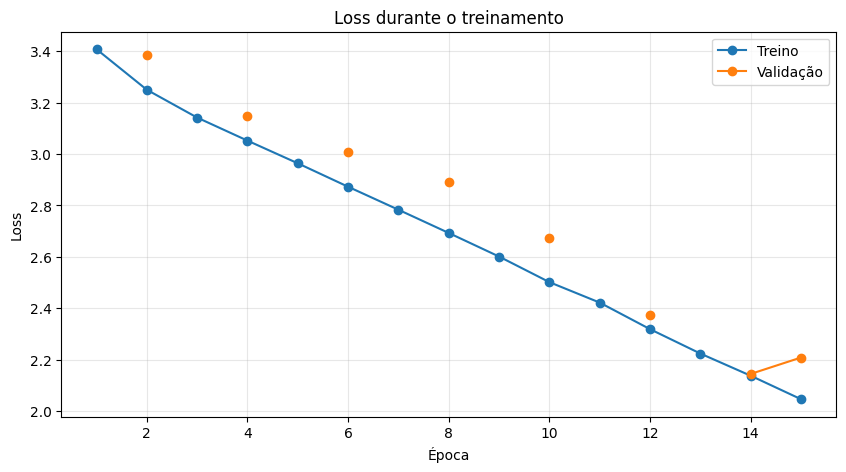

In [21]:
# 20. Curvas de Loss

epochs_range = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    marker="o",
    label="Treino"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    marker="o",
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss durante o treinamento")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

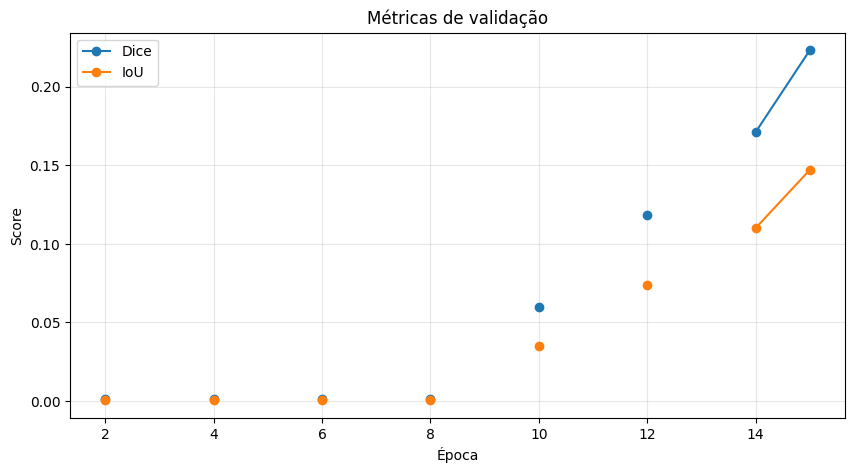

In [22]:
# 21. Curvas de Dice e IoU

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    history["val_dice"],
    marker="o",
    label="Dice"
)

plt.plot(
    epochs_range,
    history["val_iou"],
    marker="o",
    label="IoU"
)

plt.xlabel("Época")
plt.ylabel("Score")
plt.title("Métricas de validação")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [23]:
# 22. Carregar o melhor modelo

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Melhor época:", checkpoint["epoch"])
print("Val Loss:", round(checkpoint["val_loss"], 4))
print("Dice:", round(checkpoint["dice"], 4))
print("IoU:", round(checkpoint["iou"], 4))

Melhor época: 14
Val Loss: 2.1446
Dice: 0.1711
IoU: 0.1101


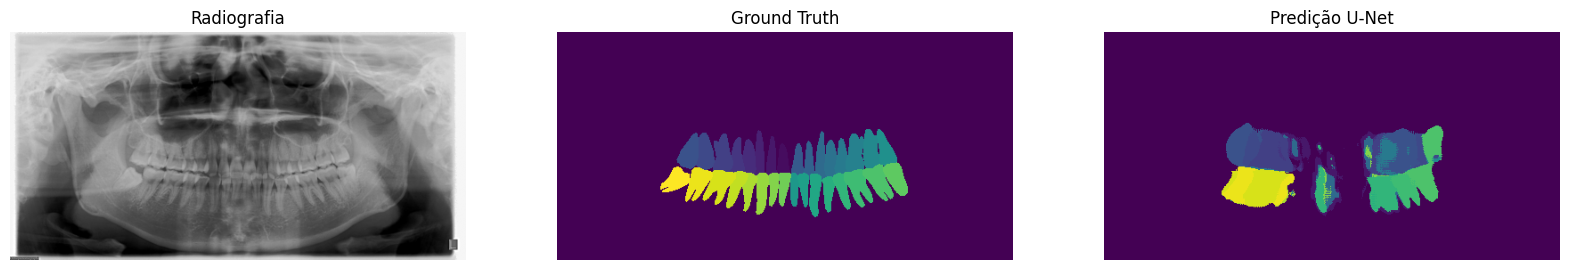

In [24]:
# 23. Visualizar previsão no conjunto de validação

images, masks = next(
    iter(val_loader)
)

model.eval()

with torch.inference_mode():

    logits = model(images)

    predictions = torch.argmax(
        logits,
        dim=1
    )

idx = 0

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.imshow(
    images[idx].squeeze(),
    cmap="gray"
)
plt.title("Radiografia")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    masks[idx],
    vmin=0,
    vmax=NUM_CLASSES - 1
)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    predictions[idx],
    vmin=0,
    vmax=NUM_CLASSES - 1
)
plt.title("Predição U-Net")
plt.axis("off")

plt.show()

## Inferência em radiografias externas sem anotação

Esta seção é independente do **teste final anotado** reservado acima.

As imagens em `dataset/test/images` não precisam ter JSON. O modelo apenas gera e salva uma máscara para cada radiografia. Como não existe Ground Truth nessa pasta, ela **não é usada para calcular Dice ou IoU**.


In [25]:
# 24. Função de inferência

def predict_image(
    model,
    image_path,
    device=DEVICE
):
    image_path = Path(image_path)

    original = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if original is None:
        raise FileNotFoundError(
            f"Não foi possível abrir a imagem: {image_path}"
        )

    original_height, original_width = (
        original.shape
    )

    resized = cv2.resize(
        original,
        (IMG_WIDTH, IMG_HEIGHT),
        interpolation=cv2.INTER_AREA
    )

    normalized = (
        resized.astype(np.float32)
        / 255.0
    )

    tensor = torch.from_numpy(
        normalized
    ).unsqueeze(0).unsqueeze(0).float()

    model.eval()

    with torch.inference_mode():

        logits = model(
            tensor.to(device)
        )

        prediction = torch.argmax(
            logits,
            dim=1
        )

    prediction = (
        prediction
        .squeeze(0)
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    prediction_original_size = cv2.resize(
        prediction,
        (original_width, original_height),
        interpolation=cv2.INTER_NEAREST
    )

    return (
        original,
        prediction_original_size
    )

In [26]:
# 25. Localizar imagens de teste

if TEST_IMAGES_DIR.exists():

    test_files = sorted([
        p
        for p in TEST_IMAGES_DIR.iterdir()
        if p.suffix.lower()
        in {
            ".jpg",
            ".jpeg",
            ".png",
            ".tif",
            ".tiff"
        }
    ])

else:

    test_files = []

    print(
        "Pasta de teste não encontrada:",
        TEST_IMAGES_DIR
    )

print(
    "Imagens de teste:",
    len(test_files)
)

Imagens de teste: 10


In [27]:
# 26. Testar uma imagem

if test_files:

    test_image_path = test_files[0]

    original, prediction = predict_image(
        model,
        test_image_path,
        DEVICE
    )

    print("Imagem:", test_image_path.name)
    print(
        "Classes previstas:",
        np.unique(prediction).tolist()
    )

else:

    print(
        "Nenhuma imagem de teste disponível."
    )

Imagem: non_perio_1272-tif_0_png.rf.83778329a8238a03c85289b415fad95c.jpg
Classes previstas: [0, 2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 14, 15, 21, 22, 23, 25, 26, 28, 30, 31, 32]


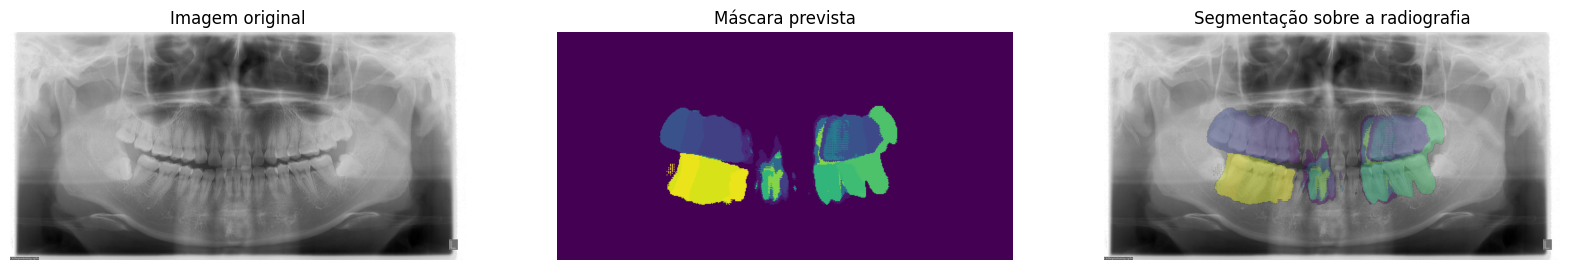

In [28]:
# 27. Visualizar a previsão

if test_files:

    plt.figure(figsize=(20, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(
        original,
        cmap="gray"
    )
    plt.title("Imagem original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(
        prediction,
        vmin=0,
        vmax=NUM_CLASSES - 1
    )
    plt.title("Máscara prevista")
    plt.axis("off")

    plt.subplot(1, 3, 3)

    plt.imshow(
        original,
        cmap="gray"
    )

    overlay = np.ma.masked_where(
        prediction == 0,
        prediction
    )

    plt.imshow(
        overlay,
        alpha=0.45,
        vmin=1,
        vmax=NUM_CLASSES - 1
    )

    plt.title(
        "Segmentação sobre a radiografia"
    )

    plt.axis("off")

    plt.show()

In [29]:
# 28. Salvar as previsões de todas as imagens de teste

PREDICTIONS_DIR = Path(
    "predictions"
)

PREDICTIONS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for image_path in tqdm(
    test_files,
    desc="Inferência"
):

    _, prediction = predict_image(
        model,
        image_path,
        DEVICE
    )

    output_path = (
        PREDICTIONS_DIR
        / f"{image_path.stem}_mask.png"
    )

    cv2.imwrite(
        str(output_path),
        prediction
    )

print(
    "Predições salvas em:",
    PREDICTIONS_DIR.resolve()
)

Inferência:   0%|          | 0/10 [00:00<?, ?it/s]

Predições salvas em: /content/predictions


# Avaliação final — conjunto de teste nunca visto

A partir deste ponto, o melhor checkpoint já foi escolhido **exclusivamente pela validação**.  
Agora o conjunto `test_dataset`, que não participou do treinamento, scheduler, early stopping ou seleção de checkpoint, é usado uma única vez para:

1. calcular **Dice final** e IoU;
2. calcular Dice por radiografia;
3. gerar três exemplos visuais representativos;
4. localizar e exibir automaticamente o pior caso;
5. resumir as métricas e configurações do modelo usado no treinamento.


In [30]:
# 29. Avaliar o melhor modelo no teste final anotado

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

model.eval()

test_confusion = torch.zeros(
    (NUM_CLASSES, NUM_CLASSES),
    dtype=torch.int64
)

running_test_loss = 0.0
per_image_results = []

with torch.inference_mode():

    for local_idx, (images, masks) in enumerate(
        tqdm(
            test_loader,
            desc="Teste final",
            leave=False
        )
    ):

        logits = model(images)

        loss = criterion(
            logits,
            masks
        )

        running_test_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        # Métricas agregadas do conjunto inteiro.
        test_confusion = update_confusion_matrix(
            test_confusion,
            predictions,
            masks,
            NUM_CLASSES
        )

        # Métricas individuais desta radiografia.
        image_confusion = torch.zeros(
            (NUM_CLASSES, NUM_CLASSES),
            dtype=torch.int64
        )

        image_confusion = update_confusion_matrix(
            image_confusion,
            predictions,
            masks,
            NUM_CLASSES
        )

        image_dice, image_iou = metrics_from_confusion(
            image_confusion
        )

        # Recupera o índice original dentro do DentalDataset.
        dataset_idx = int(
            test_dataset.indices[local_idx]
        )

        image_path, annotation_path = (
            dataset.samples[dataset_idx]
        )

        per_image_results.append(
            {
                "dataset_idx": dataset_idx,
                "image_name": image_path.name,
                "annotation_name": annotation_path.name,
                "dice": float(image_dice),
                "iou": float(image_iou),
                "image": images[0].cpu().clone(),
                "ground_truth": masks[0].cpu().clone(),
                "prediction": predictions[0].cpu().clone(),
            }
        )

test_loss = (
    running_test_loss
    / max(1, len(test_loader))
)

test_dice, test_iou = metrics_from_confusion(
    test_confusion
)

print("=" * 60)
print("RESULTADO FINAL — TESTE NUNCA VISTO")
print("=" * 60)
print(f"Test Loss : {test_loss:.4f}")
print(f"Dice final: {test_dice:.4f}")
print(f"IoU final : {test_iou:.4f}")
print(f"Radiografias avaliadas: {len(per_image_results)}")
print("=" * 60)


Teste final:   0%|          | 0/4 [00:00<?, ?it/s]

RESULTADO FINAL — TESTE NUNCA VISTO
Test Loss : 2.1944
Dice final: 0.1679
IoU final : 0.1071
Radiografias avaliadas: 4


In [31]:
# 30. Tabela de Dice/IoU por radiografia e arquivos de métricas

import csv

ranking = sorted(
    per_image_results,
    key=lambda item: item["dice"],
    reverse=True
)

metrics_csv_path = RESULTS_DIR / "dice_por_radiografia.csv"

with open(
    metrics_csv_path,
    "w",
    newline="",
    encoding="utf-8"
) as csv_file:

    writer = csv.DictWriter(
        csv_file,
        fieldnames=[
            "image_name",
            "annotation_name",
            "dice",
            "iou"
        ]
    )

    writer.writeheader()

    for item in ranking:
        writer.writerow(
            {
                "image_name": item["image_name"],
                "annotation_name": item["annotation_name"],
                "dice": f'{item["dice"]:.6f}',
                "iou": f'{item["iou"]:.6f}',
            }
        )

print("Ranking por Dice:")
for position, item in enumerate(ranking, start=1):
    print(
        f'{position:02d}. {item["image_name"]}'
        f' | Dice={item["dice"]:.4f}'
        f' | IoU={item["iou"]:.4f}'
    )

print(
    "\nMétricas por radiografia salvas em:",
    metrics_csv_path.resolve()
)


Ranking por Dice:
01. non_perio_1308-tif_0_png.rf.5db78345f8dcbf89221e4e6b6d0deaf4.jpg | Dice=0.2095 | IoU=0.1390
02. non_perio_1091-tif_0_png.rf.7b624d4e971af0226f714b017de2df7b.jpg | Dice=0.1947 | IoU=0.1295
03. non_perio_108-tif_0_png.rf.abeb76b6f345113f309f1b388d481a25.jpg | Dice=0.1328 | IoU=0.0853
04. non_perio_1316-tif_0_png.rf.1e0e6f6ef7e90d2dee28a06a8ecaa86f.jpg | Dice=0.1158 | IoU=0.0791

Métricas por radiografia salvas em: /content/results/dice_por_radiografia.csv


## Três exemplos do conjunto de teste

Para evitar escolher apenas os melhores resultados, os exemplos são selecionados automaticamente em três faixas de desempenho quando houver amostras suficientes:

- um caso com Dice alto;
- um caso próximo da mediana;
- um caso com Dice mais baixo, mas preservando o pior caso para a análise de falha.

A ordem visual segue exatamente o requisito do desafio:

**Imagem original | Predição | Ground Truth**


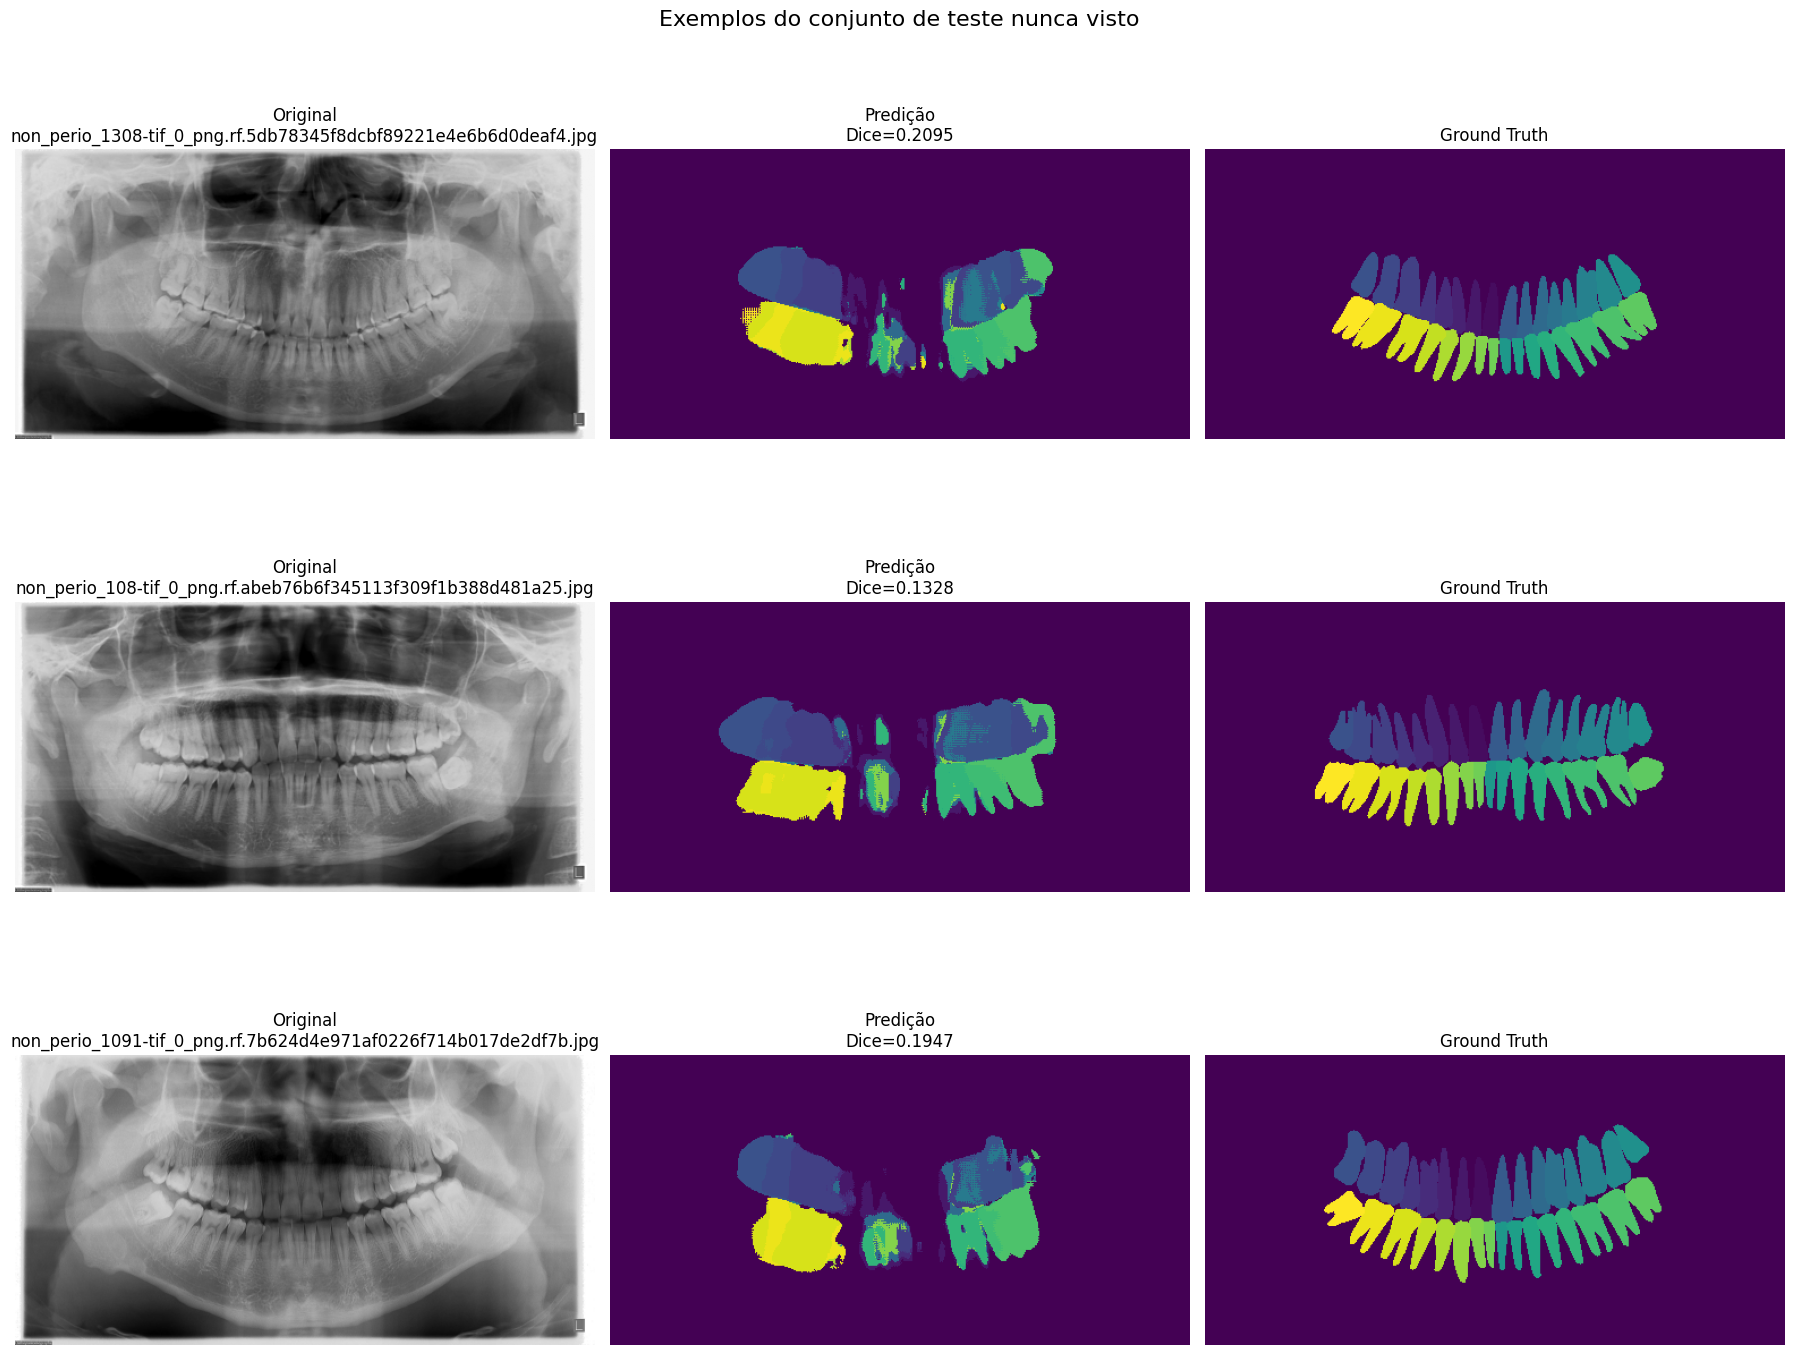

Figura salva em: /content/results/tres_exemplos_teste.png


In [32]:
# 31. Selecionar e mostrar 3 exemplos representativos do teste

def select_representative_examples(
    results,
    n_examples=3
):
    if not results:
        return []

    sorted_results = sorted(
        results,
        key=lambda item: item["dice"],
        reverse=True
    )

    if len(sorted_results) <= n_examples:
        return sorted_results

    # Melhor caso.
    selected_indices = [0]

    # Caso próximo da mediana.
    selected_indices.append(
        len(sorted_results) // 2
    )

    # Caso baixo, mas evita usar o pior caso aqui
    # para deixá-lo reservado à análise de erro.
    selected_indices.append(
        max(1, len(sorted_results) - 2)
    )

    # Remove duplicatas mantendo a ordem.
    selected_indices = list(
        dict.fromkeys(selected_indices)
    )

    # Completa caso alguma posição tenha coincidido.
    for idx in range(len(sorted_results)):
        if len(selected_indices) >= n_examples:
            break
        if idx not in selected_indices:
            selected_indices.append(idx)

    return [
        sorted_results[idx]
        for idx in selected_indices[:n_examples]
    ]


examples = select_representative_examples(
    per_image_results,
    n_examples=3
)

if not examples:
    print(
        "Não há amostras no teste final para visualizar."
    )

else:

    fig, axes = plt.subplots(
        len(examples),
        3,
        figsize=(18, 5 * len(examples))
    )

    if len(examples) == 1:
        axes = np.expand_dims(
            axes,
            axis=0
        )

    for row, item in enumerate(examples):

        image_np = (
            item["image"]
            .squeeze()
            .numpy()
        )

        prediction_np = (
            item["prediction"]
            .numpy()
        )

        ground_truth_np = (
            item["ground_truth"]
            .numpy()
        )

        axes[row, 0].imshow(
            image_np,
            cmap="gray"
        )
        axes[row, 0].set_title(
            f'Original\n{item["image_name"]}'
        )

        axes[row, 1].imshow(
            prediction_np,
            vmin=0,
            vmax=NUM_CLASSES - 1
        )
        axes[row, 1].set_title(
            f'Predição\nDice={item["dice"]:.4f}'
        )

        axes[row, 2].imshow(
            ground_truth_np,
            vmin=0,
            vmax=NUM_CLASSES - 1
        )
        axes[row, 2].set_title(
            "Ground Truth"
        )

        for col in range(3):
            axes[row, col].axis("off")

    plt.suptitle(
        "Exemplos do conjunto de teste nunca visto",
        fontsize=16
    )

    plt.tight_layout()

    examples_path = (
        RESULTS_DIR
        / "tres_exemplos_teste.png"
    )

    plt.savefig(
        examples_path,
        dpi=160,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Figura salva em:",
        examples_path.resolve()
    )


## Caso em que o modelo erra

O pior caso é escolhido **automaticamente**, usando o menor Dice entre todas as radiografias do teste final. Isso evita selecionar o erro de forma subjetiva e fornece uma evidência quantitativa da principal limitação observada.


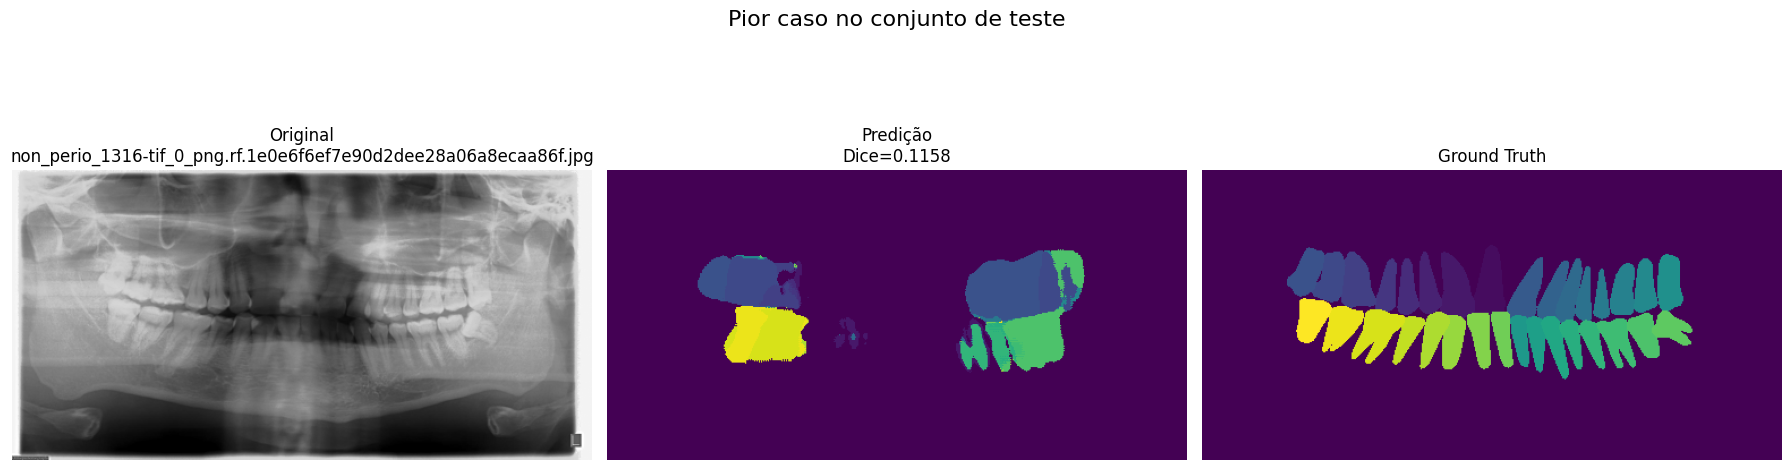

PIOR CASO
Imagem: non_perio_1316-tif_0_png.rf.1e0e6f6ef7e90d2dee28a06a8ecaa86f.jpg
Dice: 0.1158
IoU : 0.0791
Figura salva em: /content/results/pior_caso_teste.png


In [33]:
# 32. Mostrar automaticamente o pior caso do modelo

if not per_image_results:

    print(
        "Não há resultados de teste para analisar."
    )

else:

    worst_case = min(
        per_image_results,
        key=lambda item: item["dice"]
    )

    image_np = (
        worst_case["image"]
        .squeeze()
        .numpy()
    )

    prediction_np = (
        worst_case["prediction"]
        .numpy()
    )

    ground_truth_np = (
        worst_case["ground_truth"]
        .numpy()
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 6)
    )

    axes[0].imshow(
        image_np,
        cmap="gray"
    )
    axes[0].set_title(
        f'Original\n{worst_case["image_name"]}'
    )

    axes[1].imshow(
        prediction_np,
        vmin=0,
        vmax=NUM_CLASSES - 1
    )
    axes[1].set_title(
        f'Predição\nDice={worst_case["dice"]:.4f}'
    )

    axes[2].imshow(
        ground_truth_np,
        vmin=0,
        vmax=NUM_CLASSES - 1
    )
    axes[2].set_title(
        "Ground Truth"
    )

    for ax in axes:
        ax.axis("off")

    plt.suptitle(
        "Pior caso no conjunto de teste",
        fontsize=16
    )

    plt.tight_layout()

    worst_case_path = (
        RESULTS_DIR
        / "pior_caso_teste.png"
    )

    plt.savefig(
        worst_case_path,
        dpi=160,
        bbox_inches="tight"
    )

    plt.show()

    print("=" * 60)
    print("PIOR CASO")
    print("=" * 60)
    print(
        "Imagem:",
        worst_case["image_name"]
    )
    print(
        f'Dice: {worst_case["dice"]:.4f}'
    )
    print(
        f'IoU : {worst_case["iou"]:.4f}'
    )
    print(
        "Figura salva em:",
        worst_case_path.resolve()
    )


# Resumo do modelo e justificativa das escolhas

### Modelo utilizado: U-Net leve multiclasse

O notebook utiliza **uma U-Net**, sem backbone ResNet. A rede recebe uma radiografia em escala de cinza e produz, para cada pixel, uma entre **33 classes**: fundo + 32 posições dentárias.

A U-Net foi escolhida porque sua arquitetura **encoder–decoder com skip connections** é especialmente adequada para segmentação: o encoder aprende características da imagem em diferentes escalas, enquanto o decoder recupera a resolução espacial. As conexões entre encoder e decoder ajudam a preservar detalhes de contorno, importantes para delimitar dentes adjacentes.

Foi usada uma versão **leve**, com `base_channels=16`, para reduzir memória e tempo de treinamento em CPU sem alterar o princípio da arquitetura.

### Componentes de treinamento

- **CrossEntropy ponderada:** usada como função de perda multiclasse. O fundo recebe peso menor (`0.2`) porque ocupa grande parte da radiografia e poderia dominar o treinamento.
- **AdamW:** escolhido como otimizador por combinar atualização adaptativa dos pesos com `weight_decay`, ajudando a regularizar o treinamento.
- **ReduceLROnPlateau:** reduz a taxa de aprendizado quando a loss de validação deixa de melhorar.
- **Early stopping:** interrompe o treinamento após sucessivas validações sem melhora, reduzindo tempo e risco de overfitting.
- **Dice:** métrica principal da apresentação, por medir diretamente a sobreposição entre a máscara prevista e a anotação de referência.
- **IoU:** métrica complementar para tornar a avaliação mais completa.


In [34]:
# 33. Resumo final das métricas e configurações do treinamento

final_learning_rate = optimizer.param_groups[0]["lr"]

summary = {
    "modelo": "U-Net leve multiclasse",
    "classes": NUM_CLASSES,
    "parametros": int(total_params),
    "resolucao": f"{IMG_HEIGHT}x{IMG_WIDTH}",
    "batch_size": BATCH_SIZE,
    "otimizador": "AdamW",
    "learning_rate_inicial": LEARNING_RATE,
    "learning_rate_final": float(final_learning_rate),
    "loss": "CrossEntropy ponderada",
    "epocas_planejadas": EPOCHS,
    "epocas_executadas": len(history["train_loss"]),
    "melhor_epoca": int(checkpoint["epoch"]),
    "melhor_val_loss": float(checkpoint["val_loss"]),
    "melhor_val_dice": float(checkpoint["dice"]),
    "melhor_val_iou": float(checkpoint["iou"]),
    "test_loss": float(test_loss),
    "test_dice_final": float(test_dice),
    "test_iou_final": float(test_iou),
    "amostras_treino": len(train_dataset),
    "amostras_validacao": len(val_dataset),
    "amostras_teste": len(test_dataset),
    "tempo_total_min": float(
        np.sum(history["epoch_time"]) / 60
    ),
}

print("=" * 70)
print("RESUMO FINAL DO MODELO")
print("=" * 70)

for key, value in summary.items():

    if isinstance(value, float):
        print(
            f"{key:25s}: {value:.6f}"
        )
    else:
        print(
            f"{key:25s}: {value}"
        )

summary_path = (
    RESULTS_DIR
    / "resumo_metricas.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        summary,
        file,
        ensure_ascii=False,
        indent=2
    )

print(
    "\nResumo salvo em:",
    summary_path.resolve()
)

print(
    "\nMÉTRICA PRINCIPAL PARA O PITCH:"
)
print(
    f"Dice final no teste nunca visto = {test_dice:.4f}"
)


RESUMO FINAL DO MODELO
modelo                   : U-Net leve multiclasse
classes                  : 33
parametros               : 1942833
resolucao                : 256x512
batch_size               : 4
otimizador               : AdamW
learning_rate_inicial    : 0.001000
learning_rate_final      : 0.001000
loss                     : CrossEntropy ponderada
epocas_planejadas        : 15
epocas_executadas        : 15
melhor_epoca             : 14
melhor_val_loss          : 2.144644
melhor_val_dice          : 0.171080
melhor_val_iou           : 0.110051
test_loss                : 2.194441
test_dice_final          : 0.167909
test_iou_final           : 0.107061
amostras_treino          : 22
amostras_validacao       : 4
amostras_teste           : 4
tempo_total_min          : 6.446849

Resumo salvo em: /content/results/resumo_metricas.json

MÉTRICA PRINCIPAL PARA O PITCH:
Dice final no teste nunca visto = 0.1679


## Ajustes rápidos caso ainda esteja lento

Comece com os valores atuais. Se ainda estiver demorando demais:

```python
BATCH_SIZE = 2
EPOCHS = 10
```

Se o treinamento continuar inviável, a próxima redução seria `IMG_HEIGHT = 192` e `IMG_WIDTH = 384`, mas isso já sacrifica mais detalhes das bordas dos dentes.

Para o baseline da hackathon, prefira manter **256 × 512** se o tempo permitir.


U-NET + RESNET34 PRÉ-TREINADA
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:02<00:00, 32.9MB/s]


Parâmetros totais: 24,452,641
Parâmetros treináveis inicialmente: 24,452,641
Shape de entrada: torch.Size([1, 1, 256, 512])
Shape de saída: torch.Size([1, 33, 256, 512])

FASE 1 — encoder congelado


ResNet34 Epoch 1 [treino]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 01 | Train: 3.4203 | Val: 3.4174 | Dice: 0.0003 | IoU: 0.0001 | LR: [0.001] | 46.4s
✓ Melhor ResNet34 salva


...

Epoch 08 | Train: 2.4033 | Val: 2.5234 | Dice: 0.0765 | IoU: 0.0449 | LR: [1e-05, 0.0001] | 63.2s


ResNet34 Epoch 9 [treino]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 09 | Train: 2.3687 | Val: 2.5165 | Dice: 0.0838 | IoU: 0.0493 | LR: [5e-06, 5e-05] | 61.6s


ResNet34 Epoch 10 [treino]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 10 | Train: 2.3433 | Val: 2.4844 | Dice: 0.0935 | IoU: 0.0556 | LR: [5e-06, 5e-05] | 63.0s
Early stopping nesta fase.

RESULTADO FINAL — U-NET + RESNET34
Melhor época: 6
Melhor fase: FASE 2 — fine tuning
Val Loss: 2.412214
Val Dice: 0.083278
Val IoU: 0.048046
----------------------------------------------------------------------
Test Loss: 2.477412
Test Dice: 0.093018
Test IoU: 0.054929
Tempo total: 9.32 min

COMPARAÇÃO COM O BASELINE
U-Net leve:        0.167909
U-Net + ResNet34:  0.093018
Δ Dice:            -0.074891
Melhoria relativa: -44.60%

DICE POR RADIOGRAFIA
01. non_perio_1091-tif_0_png.rf.7b624d4e971af0226f714b017de2df7b.jpg | Dice=0.1150 | IoU=0.0730
02. non_perio_1308-tif_0_png.rf.5db78345f8dcbf89221e4e6b6d0deaf4.jpg | Dice=0.1038 | IoU=0.0618
03. non_perio_108-tif_0_png.rf.abeb76b6f345113f309f1b388d481a25.jpg | Dice=0.0760 | IoU=0.0443
04. non_perio_1316-tif_0_png.rf.1e0e6f6ef7e90d2dee28a06a8ecaa86f.jpg | Dice=0.0717 | IoU=0.0419


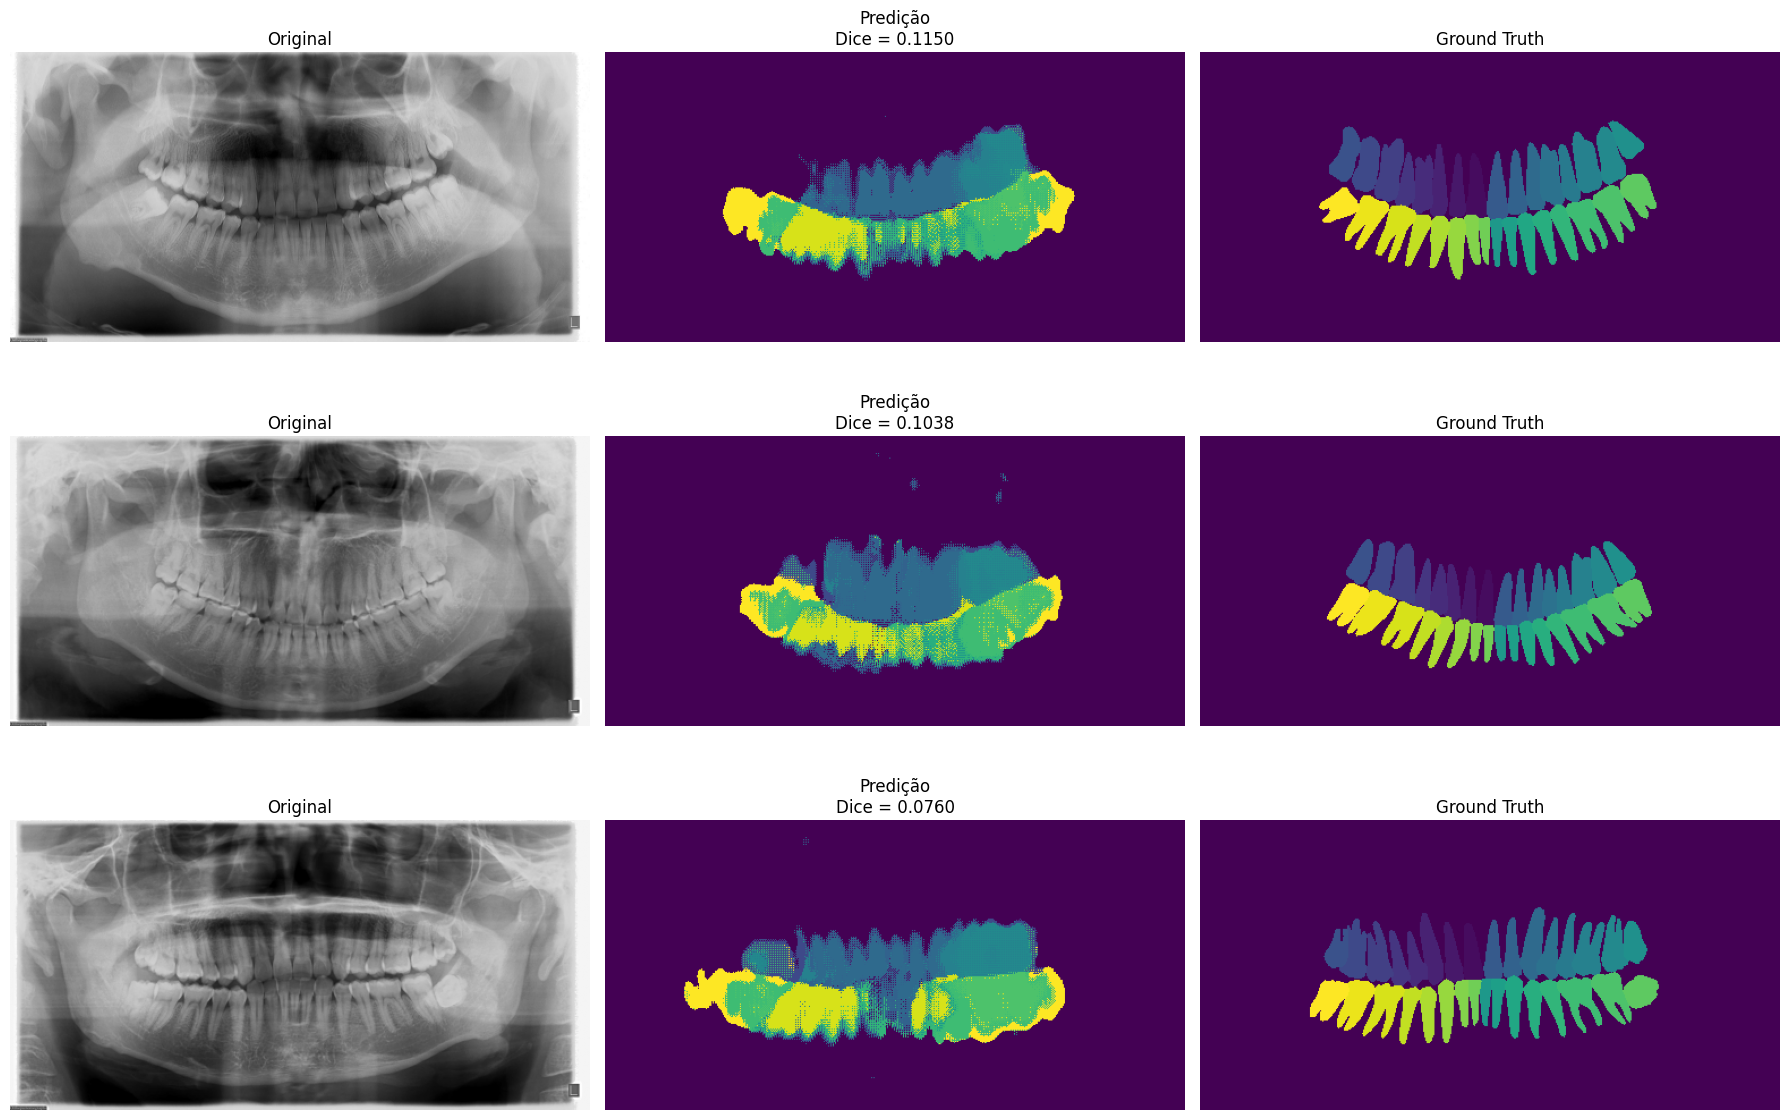

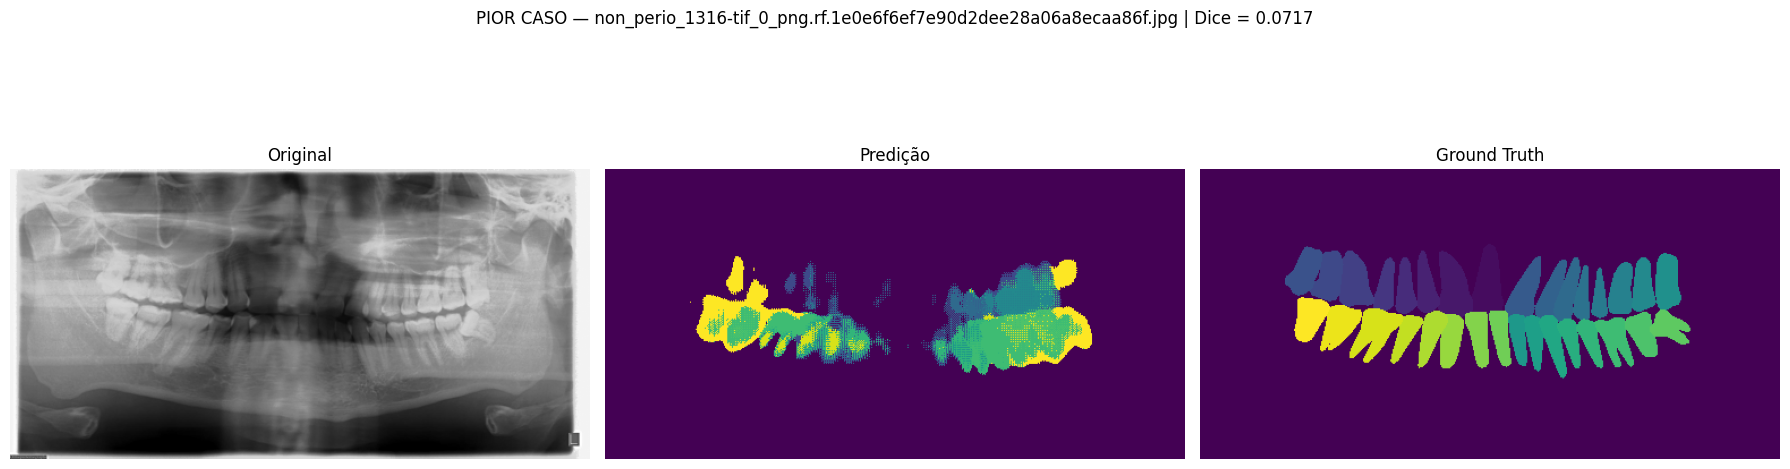


Resultados salvos em:
/content/results_resnet34


In [37]:
# ============================================================
# EXPERIMENTO 2
# U-NET + RESNET34 PRÉ-TREINADA
# ============================================================
#
# Cole esta célula DEPOIS de executar o notebook atual.
#
# Ela NÃO sobrescreve o modelo baseline.
#
# Reutiliza:
# - train_loader
# - val_loader
# - test_loader
# - test_dataset
# - NUM_CLASSES
# - DEVICE
# - class_weights
# - DoubleConv
# - update_confusion_matrix
# - metrics_from_confusion
#
# ============================================================

from torchvision.models import (
    resnet34,
    ResNet34_Weights
)

from pathlib import Path
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


# ============================================================
# 1. ARQUITETURA
# ============================================================

class UNetResNet34(nn.Module):

    def __init__(
        self,
        num_classes=33
    ):
        super().__init__()

        # ----------------------------------------------------
        # Encoder ResNet34 pré-treinado no ImageNet
        # ----------------------------------------------------

        weights = (
            ResNet34_Weights.IMAGENET1K_V1
        )

        encoder = resnet34(
            weights=weights
        )

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        self.conv1 = encoder.conv1
        self.bn1 = encoder.bn1
        self.relu = encoder.relu
        self.maxpool = encoder.maxpool

        self.layer1 = encoder.layer1
        self.layer2 = encoder.layer2
        self.layer3 = encoder.layer3
        self.layer4 = encoder.layer4

        # ----------------------------------------------------
        # Decoder U-Net
        #
        # ResNet34:
        #
        # layer1 -> 64 canais
        # layer2 -> 128
        # layer3 -> 256
        # layer4 -> 512
        #
        # ----------------------------------------------------

        self.up4 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            512,
            256
        )


        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )


        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )


        self.up1 = nn.ConvTranspose2d(
            64,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            128,
            64
        )


        self.up0 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec0 = DoubleConv(
            32,
            32
        )


        self.output = nn.Conv2d(
            32,
            num_classes,
            kernel_size=1
        )


        # ----------------------------------------------------
        # Normalização usada pelos pesos ImageNet
        # ----------------------------------------------------

        self.register_buffer(
            "imagenet_mean",
            torch.tensor(
                [0.485, 0.456, 0.406],
                dtype=torch.float32
            ).view(
                1,
                3,
                1,
                1
            )
        )

        self.register_buffer(
            "imagenet_std",
            torch.tensor(
                [0.229, 0.224, 0.225],
                dtype=torch.float32
            ).view(
                1,
                3,
                1,
                1
            )
        )


        self.encoder_frozen = False


    # ========================================================
    # PARÂMETROS DO ENCODER
    # ========================================================

    def encoder_parameters(self):

        modules = [

            self.conv1,
            self.bn1,

            self.layer1,
            self.layer2,
            self.layer3,
            self.layer4

        ]

        for module in modules:

            yield from module.parameters()


    # ========================================================
    # PARÂMETROS DO DECODER
    # ========================================================

    def decoder_parameters(self):

        modules = [

            self.up4,
            self.dec4,

            self.up3,
            self.dec3,

            self.up2,
            self.dec2,

            self.up1,
            self.dec1,

            self.up0,
            self.dec0,

            self.output

        ]

        for module in modules:

            yield from module.parameters()


    # ========================================================
    # CONGELAR ENCODER
    # ========================================================

    def freeze_encoder(self):

        for parameter in (
            self.encoder_parameters()
        ):

            parameter.requires_grad = False

        self.encoder_frozen = True


    # ========================================================
    # DESCONGELAR ENCODER
    # ========================================================

    def unfreeze_encoder(self):

        for parameter in (
            self.encoder_parameters()
        ):

            parameter.requires_grad = True

        self.encoder_frozen = False


    # ========================================================
    # EVITAR ATUALIZAÇÃO DO BATCHNORM QUANDO CONGELADO
    # ========================================================

    def train(
        self,
        mode=True
    ):

        super().train(mode)

        if (
            mode
            and
            self.encoder_frozen
        ):

            encoder_modules = [

                self.conv1,
                self.bn1,

                self.layer1,
                self.layer2,
                self.layer3,
                self.layer4

            ]

            for module in encoder_modules:

                module.eval()

        return self


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        x
    ):

        # Dataset atual:
        #
        # [B, 1, H, W]
        #
        # ResNet espera RGB:
        #
        # [B, 3, H, W]

        if x.shape[1] == 1:

            x = x.repeat(
                1,
                3,
                1,
                1
            )


        # Normalização ImageNet

        x = (
            x
            -
            self.imagenet_mean
        ) / self.imagenet_std


        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        s0 = self.conv1(x)

        s0 = self.bn1(s0)

        s0 = self.relu(s0)


        x = self.maxpool(s0)


        s1 = self.layer1(x)

        s2 = self.layer2(s1)

        s3 = self.layer3(s2)

        s4 = self.layer4(s3)


        # ----------------------------------------------------
        # DECODER
        # ----------------------------------------------------

        d4 = self.up4(s4)

        d4 = torch.cat(
            [
                d4,
                s3
            ],
            dim=1
        )

        d4 = self.dec4(d4)


        d3 = self.up3(d4)

        d3 = torch.cat(
            [
                d3,
                s2
            ],
            dim=1
        )

        d3 = self.dec3(d3)


        d2 = self.up2(d3)

        d2 = torch.cat(
            [
                d2,
                s1
            ],
            dim=1
        )

        d2 = self.dec2(d2)


        d1 = self.up1(d2)

        d1 = torch.cat(
            [
                d1,
                s0
            ],
            dim=1
        )

        d1 = self.dec1(d1)


        d0 = self.up0(d1)

        d0 = self.dec0(d0)


        return self.output(d0)


# ============================================================
# 2. FUNÇÃO DE TREINAMENTO
# ============================================================

def treinar_unet_resnet34_pre_treinada(

    frozen_epochs=5,

    finetune_epochs=15,

    patience=4,

    baseline_dice=0.167909

):


    print(
        "=" * 70
    )

    print(
        "U-NET + RESNET34 PRÉ-TREINADA"
    )

    print(
        "=" * 70
    )


    # ========================================================
    # CRIAR MODELO
    # ========================================================

    model_resnet34 = UNetResNet34(

        num_classes=NUM_CLASSES

    ).to(
        DEVICE
    )


    total_params = sum(

        p.numel()

        for p in model_resnet34.parameters()

    )


    trainable_params = sum(

        p.numel()

        for p in model_resnet34.parameters()

        if p.requires_grad

    )


    print(
        f"Parâmetros totais: "
        f"{total_params:,}"
    )

    print(
        f"Parâmetros treináveis inicialmente: "
        f"{trainable_params:,}"
    )


    # Testar shape antes de treinar

    with torch.inference_mode():

        teste = torch.randn(

            1,
            1,
            256,
            512,

            device=DEVICE

        )

        saida = model_resnet34(
            teste
        )


    print(
        "Shape de entrada:",
        teste.shape
    )

    print(
        "Shape de saída:",
        saida.shape
    )


    del teste
    del saida


    # ========================================================
    # LOSS
    # ========================================================

    criterion_resnet34 = nn.CrossEntropyLoss(

        weight=class_weights.to(
            DEVICE
        )

    )


    # ========================================================
    # CAMINHOS
    # ========================================================

    RESNET_RESULTS_DIR = Path(
        "results_resnet34"
    )

    RESNET_RESULTS_DIR.mkdir(

        parents=True,

        exist_ok=True

    )


    BEST_RESNET_PATH = (

        RESNET_RESULTS_DIR
        /
        "best_unet_resnet34.pt"

    )


    # ========================================================
    # HISTÓRICO
    # ========================================================

    history_resnet34 = []


    best_val_loss = float(
        "inf"
    )


    global_epoch = 0


    treinamento_inicio = (
        time.perf_counter()
    )


    # ========================================================
    # FUNÇÃO DE VALIDAÇÃO
    # ========================================================

    def evaluate(

        loader,

        return_per_image=False

    ):


        model_resnet34.eval()


        confusion = torch.zeros(

            (
                NUM_CLASSES,
                NUM_CLASSES
            ),

            dtype=torch.int64,

            device=DEVICE

        )


        running_loss = 0.0

        samples = 0


        per_image = []


        with torch.inference_mode():


            for batch_idx, (
                images,
                masks
            ) in enumerate(loader):


                images = images.to(

                    DEVICE,

                    non_blocking=True

                )


                masks = masks.to(

                    DEVICE,

                    non_blocking=True

                )


                logits = model_resnet34(
                    images
                )


                loss = criterion_resnet34(

                    logits,

                    masks

                )


                predictions = torch.argmax(

                    logits,

                    dim=1

                )


                batch_size = images.size(0)


                running_loss += (

                    loss.item()

                    * batch_size

                )


                samples += batch_size


                confusion = (

                    update_confusion_matrix(

                        confusion,

                        predictions,

                        masks,

                        NUM_CLASSES

                    )

                )


                # ============================================
                # DICE POR RADIOGRAFIA
                # ============================================

                if return_per_image:


                    for item_idx in range(
                        batch_size
                    ):


                        local_confusion = (

                            torch.zeros(

                                (
                                    NUM_CLASSES,
                                    NUM_CLASSES
                                ),

                                dtype=torch.int64,

                                device=DEVICE

                            )

                        )


                        local_confusion = (

                            update_confusion_matrix(

                                local_confusion,

                                predictions[
                                    item_idx
                                ],

                                masks[
                                    item_idx
                                ],

                                NUM_CLASSES

                            )

                        )


                        local_dice, local_iou = (

                            metrics_from_confusion(

                                local_confusion

                            )

                        )


                        test_position = (

                            batch_idx
                            * loader.batch_size
                            + item_idx

                        )


                        per_image.append(

                            {

                                "test_pos":
                                    int(
                                        test_position
                                    ),

                                "dice":
                                    float(
                                        local_dice
                                    ),

                                "iou":
                                    float(
                                        local_iou
                                    )

                            }

                        )


        mean_loss = (

            running_loss

            /

            max(
                1,
                samples
            )

        )


        dice, iou = (

            metrics_from_confusion(

                confusion

            )

        )


        if return_per_image:

            return (

                mean_loss,
                dice,
                iou,
                per_image

            )


        return (

            mean_loss,
            dice,
            iou

        )


    # ========================================================
    # TREINAR UMA FASE
    # ========================================================

    def train_phase(

        phase_name,

        epochs,

        optimizer,

        scheduler

    ):


        nonlocal best_val_loss



        nonlocal global_epoch


        best_phase_loss = float(
            "inf"
        )


        without_improvement = 0


        print()

        print(
            "=" * 70
        )

        print(
            phase_name
        )

        print(
            "=" * 70
        )


        for phase_epoch in range(
            epochs
        ):


            global_epoch += 1


            epoch_start = (
                time.perf_counter()
            )


            # ================================================
            # TREINO
            # ================================================

            model_resnet34.train()


            running_train_loss = 0.0

            train_samples = 0


            train_bar = tqdm(

                train_loader,

                desc=(

                    f"ResNet34 "
                    f"Epoch {global_epoch} "
                    f"[treino]"

                ),

                leave=False

            )


            for (
                images,
                masks
            ) in train_bar:


                images = images.to(

                    DEVICE,

                    non_blocking=True

                )


                masks = masks.to(

                    DEVICE,

                    non_blocking=True

                )


                optimizer.zero_grad(

                    set_to_none=True

                )


                logits = model_resnet34(
                    images
                )


                loss = criterion_resnet34(

                    logits,

                    masks

                )


                loss.backward()


                # Evita gradientes extremos

                torch.nn.utils.clip_grad_norm_(

                    model_resnet34.parameters(),

                    max_norm=1.0

                )


                optimizer.step()


                batch_size = images.size(
                    0
                )


                running_train_loss += (

                    loss.item()

                    * batch_size

                )


                train_samples += (
                    batch_size
                )


                train_bar.set_postfix(

                    loss=(
                        f"{loss.item():.4f}"
                    )

                )


            train_loss = (

                running_train_loss

                /

                max(
                    1,
                    train_samples
                )

            )


            # ================================================
            # VALIDAÇÃO
            # ================================================

            (
                val_loss,
                val_dice,
                val_iou

            ) = evaluate(

                val_loader

            )


            scheduler.step(
                val_loss
            )


            epoch_time = (

                time.perf_counter()

                -
                epoch_start

            )


            learning_rates = [

                group["lr"]

                for group
                in optimizer.param_groups

            ]


            history_resnet34.append(

                {

                    "epoch":
                        global_epoch,

                    "phase":
                        phase_name,

                    "train_loss":
                        float(
                            train_loss
                        ),

                    "val_loss":
                        float(
                            val_loss
                        ),

                    "val_dice":
                        float(
                            val_dice
                        ),

                    "val_iou":
                        float(
                            val_iou
                        ),

                    "learning_rates":
                        learning_rates,

                    "tempo_s":
                        float(
                            epoch_time
                        )

                }

            )


            print(

                f"Epoch {global_epoch:02d}"

                f" | Train: "
                f"{train_loss:.4f}"

                f" | Val: "
                f"{val_loss:.4f}"

                f" | Dice: "
                f"{val_dice:.4f}"

                f" | IoU: "
                f"{val_iou:.4f}"

                f" | LR: "
                f"{learning_rates}"

                f" | "
                f"{epoch_time:.1f}s"

            )


            # ================================================
            # MELHOR CHECKPOINT GLOBAL
            # ================================================

            if (
                val_loss
                <
                best_val_loss
            ):


                best_val_loss = (
                    val_loss
                )


                torch.save(

                    {

                        "model_state_dict":
                            model_resnet34.state_dict(),

                        "epoch":
                            global_epoch,

                        "phase":
                            phase_name,

                        "val_loss":
                            float(
                                val_loss
                            ),

                        "val_dice":
                            float(
                                val_dice
                            ),

                        "val_iou":
                            float(
                                val_iou
                            )

                    },

                    BEST_RESNET_PATH

                )


                print(
                    "✓ Melhor ResNet34 salva"
                )


            # ================================================
            # EARLY STOPPING DA FASE
            # ================================================

            if (

                val_loss

                <
                (
                    best_phase_loss
                    -
                    1e-4
                )

            ):


                best_phase_loss = (
                    val_loss
                )


                without_improvement = 0


            else:


                without_improvement += 1


            if (
                without_improvement
                >=
                patience
            ):


                print(

                    "Early stopping "
                    "nesta fase."

                )


                break


    # ========================================================
    # FASE 1
    #
    # Encoder congelado.
    #
    # Treinamos apenas o decoder.
    # ========================================================

    model_resnet34.freeze_encoder()


    optimizer_frozen = torch.optim.AdamW(

        model_resnet34.decoder_parameters(),

        lr=1e-3,

        weight_decay=1e-4

    )


    scheduler_frozen = (

        torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer_frozen,

            mode="min",

            factor=0.5,

            patience=1

        )

    )


    train_phase(

        phase_name=(
            "FASE 1 — encoder congelado"
        ),

        epochs=frozen_epochs,

        optimizer=optimizer_frozen,

        scheduler=scheduler_frozen

    )


    # ========================================================
    # FASE 2
    #
    # Fine tuning.
    #
    # Encoder é descongelado, mas recebe LR bem menor.
    # ========================================================

    model_resnet34.unfreeze_encoder()


    optimizer_finetune = torch.optim.AdamW(

        [

            {

                "params":
                    list(
                        model_resnet34.encoder_parameters()
                    ),

                "lr":
                    1e-5

            },

            {

                "params":
                    list(
                        model_resnet34.decoder_parameters()
                    ),

                "lr":
                    1e-4

            }

        ],

        weight_decay=1e-4

    )


    scheduler_finetune = (

        torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer_finetune,

            mode="min",

            factor=0.5,

            patience=2

        )

    )


    train_phase(

        phase_name=(
            "FASE 2 — fine tuning"
        ),

        epochs=finetune_epochs,

        optimizer=optimizer_finetune,

        scheduler=scheduler_finetune

    )


    # ========================================================
    # CARREGAR MELHOR CHECKPOINT
    # ========================================================

    checkpoint = torch.load(

        BEST_RESNET_PATH,

        map_location=DEVICE

    )


    model_resnet34.load_state_dict(

        checkpoint[
            "model_state_dict"
        ]

    )


    model_resnet34.eval()


    # ========================================================
    # TESTE FINAL
    #
    # Somente agora o teste é utilizado.
    # ========================================================

    (

        test_loss,

        test_dice,

        test_iou,

        per_image

    ) = evaluate(

        test_loader,

        return_per_image=True

    )


    treinamento_total = (

        time.perf_counter()

        -
        treinamento_inicio

    )


    # ========================================================
    # NOMES DAS RADIOGRAFIAS
    # ========================================================

    def get_test_name(
        position
    ):

        try:

            original_index = (

                test_dataset.indices[
                    position
                ]

            )


            image_path, _ = (

                test_dataset
                .dataset
                .samples[
                    original_index
                ]

            )


            return (
                image_path.name
            )


        except Exception:

            return (
                f"teste_{position:02d}"
            )


    for item in per_image:

        item["arquivo"] = (

            get_test_name(
                item["test_pos"]
            )

        )


    # ========================================================
    # RESULTADOS
    # ========================================================

    print()

    print(
        "=" * 70
    )

    print(
        "RESULTADO FINAL — U-NET + RESNET34"
    )

    print(
        "=" * 70
    )

    print(
        f"Melhor época: "
        f"{checkpoint['epoch']}"
    )

    print(
        f"Melhor fase: "
        f"{checkpoint['phase']}"
    )

    print(
        f"Val Loss: "
        f"{checkpoint['val_loss']:.6f}"
    )

    print(
        f"Val Dice: "
        f"{checkpoint['val_dice']:.6f}"
    )

    print(
        f"Val IoU: "
        f"{checkpoint['val_iou']:.6f}"
    )

    print(
        "-" * 70
    )

    print(
        f"Test Loss: "
        f"{test_loss:.6f}"
    )

    print(
        f"Test Dice: "
        f"{test_dice:.6f}"
    )

    print(
        f"Test IoU: "
        f"{test_iou:.6f}"
    )

    print(
        f"Tempo total: "
        f"{treinamento_total / 60:.2f} min"
    )


    # ========================================================
    # COMPARAÇÃO COM BASELINE
    # ========================================================

    ganho_absoluto = (

        test_dice
        -
        baseline_dice

    )


    ganho_percentual = (

        ganho_absoluto
        /
        max(
            baseline_dice,
            1e-8
        )
        *
        100

    )


    print()

    print(
        "=" * 70
    )

    print(
        "COMPARAÇÃO COM O BASELINE"
    )

    print(
        "=" * 70
    )

    print(
        f"U-Net leve:        "
        f"{baseline_dice:.6f}"
    )

    print(
        f"U-Net + ResNet34:  "
        f"{test_dice:.6f}"
    )

    print(
        f"Δ Dice:            "
        f"{ganho_absoluto:+.6f}"
    )

    print(
        f"Melhoria relativa: "
        f"{ganho_percentual:+.2f}%"
    )


    # ========================================================
    # RANKING DAS RADIOGRAFIAS
    # ========================================================

    ranking = sorted(

        per_image,

        key=lambda item:
            item["dice"],

        reverse=True

    )


    print()

    print(
        "=" * 70
    )

    print(
        "DICE POR RADIOGRAFIA"
    )

    print(
        "=" * 70
    )


    for rank, item in enumerate(

        ranking,

        start=1

    ):

        print(

            f"{rank:02d}. "

            f"{item['arquivo']}"

            f" | Dice="
            f"{item['dice']:.4f}"

            f" | IoU="
            f"{item['iou']:.4f}"

        )


    # ========================================================
    # FUNÇÃO PARA GERAR PREDIÇÃO DE UMA AMOSTRA
    # ========================================================

    def predict_test_position(
        position
    ):


        image, ground_truth = (

            test_dataset[
                position
            ]

        )


        with torch.inference_mode():


            logits = model_resnet34(

                image
                .unsqueeze(0)
                .to(DEVICE)

            )


            prediction = torch.argmax(

                logits,

                dim=1

            )[0]


        return (

            image.squeeze().cpu().numpy(),

            prediction.cpu().numpy(),

            ground_truth.cpu().numpy()

        )


    # ========================================================
    # PIOR CASO
    # ========================================================

    worst = min(

        per_image,

        key=lambda item:
            item["dice"]

    )


    worst_position = (
        worst["test_pos"]
    )


    # ========================================================
    # ESCOLHER 3 EXEMPLOS
    #
    # Com 4 imagens no teste:
    # deixa o pior caso separado
    # e usa as outras 3 como exemplos.
    # ========================================================

    candidates = [

        item

        for item in ranking

        if (
            item["test_pos"]
            !=
            worst_position
        )

    ]


    if len(candidates) >= 3:

        example_positions = [

            item["test_pos"]

            for item
            in candidates[:3]

        ]

    else:

        example_positions = [

            item["test_pos"]

            for item
            in ranking[:3]

        ]


    # ========================================================
    # FIGURA — 3 EXEMPLOS
    # ========================================================

    fig, axes = plt.subplots(

        3,
        3,

        figsize=(
            18,
            12
        )

    )


    for row, position in enumerate(

        example_positions

    ):


        (
            image,
            prediction,
            ground_truth

        ) = predict_test_position(
            position
        )


        dice_item = next(

            item["dice"]

            for item in per_image

            if (
                item["test_pos"]
                ==
                position
            )

        )


        axes[row, 0].imshow(

            image,

            cmap="gray"

        )

        axes[row, 0].set_title(

            "Original"

        )


        axes[row, 1].imshow(

            prediction,

            vmin=0,

            vmax=NUM_CLASSES - 1

        )

        axes[row, 1].set_title(

            f"Predição\n"
            f"Dice = {dice_item:.4f}"

        )


        axes[row, 2].imshow(

            ground_truth,

            vmin=0,

            vmax=NUM_CLASSES - 1

        )

        axes[row, 2].set_title(

            "Ground Truth"

        )


        for col in range(3):

            axes[
                row,
                col
            ].axis(
                "off"
            )


    plt.tight_layout()


    examples_path = (

        RESNET_RESULTS_DIR
        /
        "tres_exemplos_resnet34.png"

    )


    plt.savefig(

        examples_path,

        dpi=150,

        bbox_inches="tight"

    )


    plt.show()


    # ========================================================
    # FIGURA — PIOR CASO
    # ========================================================

    (
        worst_image,
        worst_prediction,
        worst_ground_truth

    ) = predict_test_position(

        worst_position

    )


    fig, axes = plt.subplots(

        1,
        3,

        figsize=(
            18,
            6
        )

    )


    axes[0].imshow(

        worst_image,

        cmap="gray"

    )

    axes[0].set_title(

        "Original"

    )


    axes[1].imshow(

        worst_prediction,

        vmin=0,

        vmax=NUM_CLASSES - 1

    )

    axes[1].set_title(

        "Predição"

    )


    axes[2].imshow(

        worst_ground_truth,

        vmin=0,

        vmax=NUM_CLASSES - 1

    )

    axes[2].set_title(

        "Ground Truth"

    )


    for axis in axes:

        axis.axis(
            "off"
        )


    plt.suptitle(

        f"PIOR CASO — "
        f"{worst['arquivo']} | "
        f"Dice = {worst['dice']:.4f}"

    )


    plt.tight_layout()


    worst_path = (

        RESNET_RESULTS_DIR
        /
        "pior_caso_resnet34.png"

    )


    plt.savefig(

        worst_path,

        dpi=150,

        bbox_inches="tight"

    )


    plt.show()


    # ========================================================
    # SALVAR RESUMO
    # ========================================================

    resumo = {

        "modelo":
            "U-Net + ResNet34 pré-treinada",

        "encoder":
            "ResNet34",

        "pre_treinamento":
            "ImageNet-1K",

        "classes":
            NUM_CLASSES,

        "parametros":
            total_params,

        "frozen_epochs_planejadas":
            frozen_epochs,

        "finetune_epochs_planejadas":
            finetune_epochs,

        "melhor_epoca":
            checkpoint["epoch"],

        "melhor_fase":
            checkpoint["phase"],

        "val_loss":
            checkpoint["val_loss"],

        "val_dice":
            checkpoint["val_dice"],

        "val_iou":
            checkpoint["val_iou"],

        "test_loss":
            float(
                test_loss
            ),

        "test_dice":
            float(
                test_dice
            ),

        "test_iou":
            float(
                test_iou
            ),

        "baseline_dice":
            float(
                baseline_dice
            ),

        "ganho_dice":
            float(
                ganho_absoluto
            ),

        "ganho_percentual":
            float(
                ganho_percentual
            ),

        "tempo_total_min":
            float(
                treinamento_total / 60
            ),

        "amostras_treino":
            len(
                train_dataset
            ),

        "amostras_validacao":
            len(
                val_dataset
            ),

        "amostras_teste":
            len(
                test_dataset
            )

    }


    resumo_path = (

        RESNET_RESULTS_DIR
        /
        "resumo_resnet34.json"

    )


    with open(

        resumo_path,

        "w",

        encoding="utf-8"

    ) as file:


        json.dump(

            resumo,

            file,

            indent=4,

            ensure_ascii=False

        )


    print()

    print(
        "Resultados salvos em:"
    )

    print(
        RESNET_RESULTS_DIR.resolve()
    )


    # ========================================================
    # RETORNO
    # ========================================================

    return {

        "model":
            model_resnet34,

        "history":
            history_resnet34,

        "test_dice":
            test_dice,

        "test_iou":
            test_iou,

        "test_loss":
            test_loss,

        "per_image":
            per_image,

        "summary":
            resumo

    }


# ============================================================
# 3. EXECUTAR O EXPERIMENTO
# ============================================================

resultado_resnet34 = (

    treinar_unet_resnet34_pre_treinada(

        frozen_epochs=5,

        finetune_epochs=15,

        patience=4,

        baseline_dice=0.167909

    )

)


# Modelo final disponível nesta variável:

model_resnet34 = (

    resultado_resnet34[
        "model"
    ]

)